# Runs all QM8 experiments with the full dataset!

### !! TODO check which shuffler you're using ##

Need to set up the weird stratified method...

(Remember that the atomization energy is the energy required to form 1 mol of gaseous atoms from 1 mol of the molecule in its standard state under standard conditions)

Apparently 0.015 is what multitask will get, and 0.0143 is the best (MPNN)

In [1]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem
import rdkit.Chem.AllChem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face

# $UN THIS
data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\QM8"
test_file='qm8.csv'
data_file_name='qm8_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset


print(f"DeepChem version: {dc.__version__}")

TensorFlow version: 2.3.0
DeepChem version: 2.5.0


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge

In [3]:
hdf5_file_name='qm8_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	21747
num_of_molecules is:	 128
MolID: count
Counter({127: 21620, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1})


In [4]:
sum([1 for x in fh['molID'][:] if x == 127])

21620

In [5]:
fh.keys()

<KeysViewHDF5 ['E1-CAM', 'E1-CC2', 'E1-PBE0', 'E1-PBE0_2', 'E2-CAM', 'E2-CC2', 'E2-PBE0', 'E2-PBE0_2', 'PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'f1-CAM', 'f1-CC2', 'f1-PBE0', 'f1-PBE0_2', 'f2-CAM', 'f2-CC2', 'f2-PBE0', 'f2-PBE0_2', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'wasser_1', 'wasser_2', 'wasser_3']>

In [128]:
fh['u0_atom'][:]

array([ -417.96,  -712.42,  -564.21, ..., -1523.  , -1778.6 , -1531.9 ],
      dtype=float32)

In [59]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list = ['E1-CC2', 'E2-CC2', 'f1-CC2', 'f2-CC2', 'E1-PBE0', 'E2-PBE0',
       'f1-PBE0', 'f2-PBE0', 'E1-PBE0', 'E2-PBE0', 'f1-PBE0', 'f2-PBE0',
       'E1-CAM', 'E2-CAM', 'f1-CAM', 'f2-CAM']
#task_list = ['E1 -CC2']

In [121]:
X_data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [7]:
def load_all_hdf5(fh,
                  num_of_rows, 
                  column_headers):
    """If dataset is small enough, load it all into memory
    fh = file handle
    num_of_rows = number of rows of data (i.e. molecules)
    column_headers into the hdf5 file"""
    data = np.zeros((num_of_rows,len(column_headers)))
    for key_num in range(len(column_headers)):
        key = column_headers[key_num]
        #print(key_num)
        d=fh[key]
        data[:,key_num] = d
    return data

X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = fh['SMILES']

(array([16561.,  2000.,  1109.,   772.,   632.,   294.,   204.,   102.,
           52.,    21.]),
 array([-1.25370003e-04,  5.48718736e-02,  1.09869117e-01,  1.64866361e-01,
         2.19863605e-01,  2.74860848e-01,  3.29858092e-01,  3.84855335e-01,
         4.39852579e-01,  4.94849823e-01,  5.49847066e-01]),
 <BarContainer object of 10 artists>)

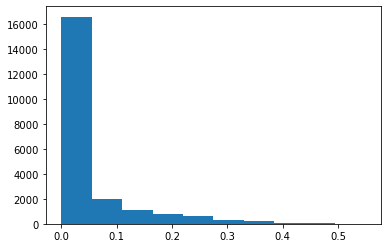

In [13]:
plt.hist([x[3] for x in y_data])

In [60]:
# y been normalise here
#X_data = topol_feat_mat
#y_data = pd.DataFrame(my_starting_dataset.y, columns=tasks)
my_topol_data = dc.data.NumpyDataset(X=X_data, y=y_data, ids=SMILES_list)
print(my_topol_data)
#len(y_data)
#y_data.head()
topol_dataset = dc.data.DiskDataset.from_numpy(my_topol_data)

my_PCA_data = dc.data.NumpyDataset(X=PCA_X_data, y=y_data, ids=SMILES_list)
PCA_dataset = dc.data.DiskDataset.from_numpy(my_PCA_data)
PCA_dataset = dc.data.DiskDataset.from_numpy(PCA_X_data, y_data, ids=SMILES_list)

<NumpyDataset X.shape: (21747, 18), y.shape: (21747, 16), w.shape: (21747, 1), task_names: [ 0  1  2 ... 13 14 15]>


In [15]:
topol_dataset = dc.data.DiskDataset.from_numpy(X_data, y_data, ids=SMILES_list)

In [16]:
topol_dataset.ids

array(['[H]C([H])([H])[H]', '[H]N([H])[H]', '[H]O[H]', ...,
       '[H]N1C([H])([H])C([H])([H])[C@]1([H])C(F)(F)F',
       '[H]C1([H])O[C@@]([H])(C(F)(F)F)C1([H])[H]',
       '[H]C1([H])OC([H])([H])C1([H])C(F)(F)F'], dtype=object)

In [148]:
tasks, datasets, transformers_ECFP = dc.molnet.load_qm8(
    shard_size=2000, featurizer="ECFP", splitter="stratified")
train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = datasets
len(train_dataset_ECFP) + len(valid_dataset_ECFP) + len(test_dataset_ECFP)

array([-1.16190034])

In [43]:
featurizer_CM_eig = dc.feat.CoulombMatrixEig(max_atoms=23)
tasks, datasets, transformers_CM_eig = dc.molnet.load_qm8(
    shard_size=2000, featurizer=featurizer_CM_eig, splitter="stratified")
train_dataset_CM_eig, valid_dataset_CM_eig, test_dataset_CM_eig = datasets
len(train_dataset_CM_eig) + len(valid_dataset_CM_eig) + len(test_dataset_CM_eig)

C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\deepchem\feat\molecule_featurizers\coulomb_matrices.py:138: RuntimeWarning: divide by zero encountered in true_divide
  m = np.outer(z, z) / d
Failed to featurize datapoint 5620, [H]C([H])([H])C([H])(C([H])([H])[H])C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 5621, [H]OC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])C([H])(C([H])([H])[H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 5622, [H]C([H])([H])C([H])(OC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 5623, [H]O[C@]([H])(C([H])([H])[H])C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 5625, [H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C(C([H])([H])[H])(C([H])([H

Exception message: 
Failed to featurize datapoint 6316, [H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C1(C([H])([H])[H])C([H])([H])C1([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 6325, [H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])[C@]1([H])C([H])([H])[C@]1([H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 6332, [H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])C1([H])C([H])([H])C1([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 6390, [H]C([H])([H])C(C([H])([H])[H])(C([H])([H])[H])C1([H])C([H])([H])C([H])([H])C1([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 6554, [H]OC([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])(C([H])([H])[H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 6559, [H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])(C([H])([H])[H])C([H])([H])[H]. Appending empt

Exception message: 
Failed to featurize datapoint 442, [H]OC([H])([H])[C@]([H])(C([H])([H])[H])[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 443, [H]C([H])([H])O[C@]([H])(C([H])([H])[H])[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 444, [H]O[C@@]([H])(C([H])([H])C([H])([H])[H])[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 907, [H].[H]OC([H])([H])C([H])([H])C([H])([H])[C@@]([H])([C]([H])C([H])([H])[H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 908, [H]C([H])([H])OC([H])([H])C([H])([H])[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 912, [H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])[C@@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]. App

Exception message: 
Failed to featurize datapoint 5165, [H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])[C@@]1([H])C([H])([H])[C@@]1([H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 5262, [H]C([H])([H])C([H])([H])[C@@]1([H])C([H])([H])[C@@]1([H])C([H])(C([H])([H])[H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 5323, [H]C([H])([H])C([H])(C([H])([H])[H])C1([H])C([H])([H])C([H])([H])C([H])([H])C1([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 5333, [H]C([H])([H])C([H])(C([H])([H])[H])[C@@]1([H])[C@@]([H])(C([H])([H])[H])[C@@]1([H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 6222, [H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H]. Appending empty array
Exception message: 
Failed to featurize datapoint 6223, [H]OC([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])C([H])([

21584

In [ ]:
featurizer_weave = dc.feat.WeaveFeaturizer()
tasks, datasets, transformers_weave = dc.molnet.load_qm8(
    shard_size=2000, featurizer=featurizer_weave, splitter="stratified")
train_dataset_weave, valid_dataset_weave, test_dataset_weave = datasets
len(train_dataset_weave) + len(valid_dataset_weave) + len(test_dataset_weave)

In [ ]:
featurizer_rdkit = dc.feat.RDKitDescriptors
tasks, datasets, transformers_rdkit = dc.molnet.load_qm8(
    shard_size=2000, featurizer=featurizer_rdkit, splitter="stratified")
train_dataset_rdkit, valid_dataset_rdkit, test_dataset_rdkit = datasets
len(train_dataset_rdkit) + len(valid_dataset_rdkit) + len(test_dataset_rdkit)

In [149]:
train_dataset_ECFP.ids[-1]

'[H]C1([H])C([H])([H])C([H])([H])C2(C1([H])[H])C([H])([H])C2([H])[H]'

In [150]:
#tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
#    shard_size=2000, featurizer="ECFP", splitter="stratified")
#_, _, small_dataset = datasets
## we're jsut going to use the test dataset here to test the code
#splitter = dc.splits.RandomSplitter()
#train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = splitter.train_valid_test_split(
#  dataset=small_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
#)

# We want to know the RMS, averaged across tasks
#avg_rms = dc.metrics.Metric(dc.metrics.mae_score)

In [235]:
PCA_dataset.ids

array(['[H].[H].[H][C][H]', '[H]C([H])([H])C([H])([H])[H]',
       '[H]C([H])=C([H])[H]', ...,
       '[H]/C(=C(\\C#N)C([H])([H])C([H])([H])[H])C([H])([H])[H]',
       '[H]C([H])=C1C([H])([H])C([H])=C([H])[C@]1([H])C([H])([H])[H]',
       '[H]C1([H])C([H])([H])C([H])([H])C2(C1([H])[H])C([H])([H])C2([H])[H]'],
      dtype=object)

In [19]:
Splitter_Object = dc.splits.RandomSplitter()
train_dataset_tf, valid_dataset_tf, test_dataset_tf = Splitter_Object.train_valid_test_split(
    dataset=topol_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)

Splitter_Object_PCA = dc.splits.SingletaskStratifiedSplitter()
train_dataset_pca, valid_dataset_pca, test_dataset_pca = Splitter_Object_PCA.train_valid_test_split(
    dataset=PCA_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)



In [182]:
train_dataset_tf.ids

array(['[H]c1sc([H])c2c1N([H])C2([H])[H]',
       '[H]OC([H])([H])c1snc([H])c1[H]', '[H]Oc1c(O[H])c([H])n([H])c1[H]',
       ..., '[H]OC([H])([H])C([H])([H])[H]', '[H]N1C([H])([H])C1([H])[H]',
       '[H][C]([H])[N]OC([H])([H])[H]'], dtype=object)

In [20]:
untransformed_train_y = transformers[0].untransform(orig_test_dataset.y)
my_untransformed_dataset = dc.data.NumpyDataset(X=X_data, y=untransformed_train_y[0:69])
print(my_untransformed_dataset.y[:5])
# y been normalise here
X_data_un = topol_feat_mat
y_data_un = pd.DataFrame(my_untransformed_dataset.y, columns=tasks)

NameError: name 'transformers' is not defined

In [153]:
(train_scores,test_scores) = h.run_repeated_RF_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_estimators=100,
    test_set_size=10,
    validate_set_size=10)

out=h.nice_stats_outputter(
    train_scores, 
    test_scores, 
    validate_scores='')
(min_train_RF_large, mean_train_RF_large, std_error_train_RF_large, max_train_RF_large,
                min_test_RF_large, mean_test_RF_large, std_error_test_RF_large, max_test_RF_large)=out
RF_large_train_scores=train_scores
RF_large_test_scores=test_scores

C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X_data, train_y_data)
C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry\helper_functions.py:650: DataConversionWarning: A column-vector y was passed

ValueError: too many values to unpack (expected 2)

In [ ]:
h.nice_stats_outputter(
    train_scores, 
    test_scores, 
    validate_scores='')

In [21]:
def run_repeated_keras_NN_tests_mae(
    X_data,
    y_data,
    keras_model=None,
    num_of_repeats=10,
    num_of_epochs=100,
    test_set_size=int(num_of_molecules*0.1),
    validate_set_size=int(num_of_molecules*0.1),
    metric1=dc.metrics.Metric(dc.metrics.pearson_r2_score),
    metric2 = dc.metrics.Metric(dc.metrics.mae_score)
    ):

    num_of_proteins = len(X_data)
    size_of_output = len(y_data.columns)

    train_scores_r2=[]
    test_scores_r2=[]
    train_scores_mae=[]
    test_scores_mae=[]

    for trial in range(num_of_repeats):
        (train_X_data, ###
         train_y_data,
         test_X_data,
         test_y_data,
         validate_X_data,
         validate_y_data) = h.set_up_train_test_validate(
            X_data,
            y_data,
            test_set_size=test_set_size,
            validate_set_size=validate_set_size,
            verbose=True)
        # put data into a dataset for input to keras
        train_dataset=dc.data.NumpyDataset(train_X_data, train_y_data)
        test_dataset=dc.data.NumpyDataset(test_X_data, test_y_data)
        # choose metric(s)
        metric1 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
        metric2 = dc.metrics.Metric(dc.metrics.mae_score)
        # make deepchem model from keras model
        if keras_model == None:
            keras_model = h.create_keras_model(size_of_output=size_of_output)
        model = dc.models.KerasModel(keras_model, dc.models.losses.L2Loss())
        # fit it
        model.fit(train_dataset, nb_epoch=num_of_epochs)
        train_score = model.evaluate(train_dataset, [metric1, metric2])
        test_score = model.evaluate(test_dataset, [metric1, metric2])
        train_score_r2 = train_score['pearson_r2_score']
        test_score_r2 = test_score['pearson_r2_score']
        train_score_mae = train_score['mae_score']
        test_score_mae = test_score['mae_score']
        print('R2 error\ttrain {:.3}, \t test: {:.3}'.format(train_score_r2, test_score_r2))
        print('MAE error\ttrain {:.3}, \t test: {:.3}'.format(train_score_mae, test_score_mae))
        train_scores_r2.append(train_score_r2)
        test_scores_r2.append(test_score_r2)
        train_scores_mae.append(train_score_mae)
        test_scores_mae.append(test_score_mae)

    print(train_scores_r2)
    print(test_scores_r2)
    out=(train_scores_r2, test_scores_r2, train_scores_mae, test_scores_mae, keras_model)
    return out

In [22]:
keras_model = h.create_keras_model()
out=run_repeated_keras_NN_tests_mae(
    train_dataset_tf.X,
    train_dataset_tf.y,
    keras_model=keras_model,
    num_of_repeats=5,
    num_of_epochs=100,
    test_set_size=int(num_of_molecules*0.1),
    validate_set_size=int(num_of_molecules*0.1))

(train_scores_r2, \
 test_scores_r2, train_scores_rmse, \
 test_scores_rmse, trained_keras_model) = out

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

## Topological features

In [61]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_tf, validate_scores_tf, test_scores_tf = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=18,
        layer_sizes=[1000,1000,500,20],
        dropouts=0.4,
        learning_rate=0.01,
        residual=True)
    callback = dc.models.ValidationCallback(valid_dataset_tf, 5, metric1)
    model.fit(train_dataset_tf, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_tf.append(model.evaluate(train_dataset_tf, 
                                       metric1)['mae_score'])
    validate_scores_tf.append(model.evaluate(valid_dataset_tf, 
                                          metric1)['mae_score'])
    test_scores_tf.append(model.evaluate(test_dataset_tf, 
                                      metric1)['mae_score'])

Step 5 validation: mae_score=1.10969
Step 10 validation: mae_score=0.815418
Step 15 validation: mae_score=0.204947
Step 20 validation: mae_score=0.268514
Step 25 validation: mae_score=0.189774
Step 30 validation: mae_score=0.172987
Step 35 validation: mae_score=0.204047
Step 40 validation: mae_score=0.229763
Step 45 validation: mae_score=0.252186
Step 50 validation: mae_score=0.239626
Step 55 validation: mae_score=0.235275
Step 60 validation: mae_score=0.242654
Step 65 validation: mae_score=0.255639
Step 70 validation: mae_score=0.25301
Step 75 validation: mae_score=0.243831
Step 80 validation: mae_score=0.251692
Step 85 validation: mae_score=0.263824
Step 90 validation: mae_score=0.252818
Step 95 validation: mae_score=0.239282
Step 100 validation: mae_score=0.237454
Step 105 validation: mae_score=0.242822
Step 110 validation: mae_score=0.24527
Step 115 validation: mae_score=0.229747
Step 120 validation: mae_score=0.231946
Step 125 validation: mae_score=0.229424
Step 130 validation: ma

Step 1040 validation: mae_score=0.109904
Step 1045 validation: mae_score=0.10537
Step 1050 validation: mae_score=0.103558
Step 1055 validation: mae_score=0.106654
Step 1060 validation: mae_score=0.103753
Step 1065 validation: mae_score=0.107331
Step 1070 validation: mae_score=0.105106
Step 1075 validation: mae_score=0.104561
Step 1080 validation: mae_score=0.101984
Step 1085 validation: mae_score=0.10279
Step 1090 validation: mae_score=0.108157
Step 1095 validation: mae_score=0.10079
Step 1100 validation: mae_score=0.104504
Step 1105 validation: mae_score=0.106101
Step 1110 validation: mae_score=0.107128
Step 1115 validation: mae_score=0.104003
Step 1120 validation: mae_score=0.105284
Step 1125 validation: mae_score=0.106343
Step 1130 validation: mae_score=0.0986985
Step 1135 validation: mae_score=0.105248
Step 1140 validation: mae_score=0.0990494
Step 1145 validation: mae_score=0.103232
Step 1150 validation: mae_score=0.107224
Step 1155 validation: mae_score=0.102738
Step 1160 validat

Step 2030 validation: mae_score=0.0620604
Step 2035 validation: mae_score=0.0611729
Step 2040 validation: mae_score=0.0620005
Step 2045 validation: mae_score=0.0605153
Step 2050 validation: mae_score=0.0609807
Step 2055 validation: mae_score=0.0582866
Step 2060 validation: mae_score=0.0584498
Step 2065 validation: mae_score=0.0592207
Step 2070 validation: mae_score=0.0601803
Step 2075 validation: mae_score=0.0620487
Step 2080 validation: mae_score=0.061269
Step 2085 validation: mae_score=0.0594648
Step 2090 validation: mae_score=0.060044
Step 2095 validation: mae_score=0.058179
Step 2100 validation: mae_score=0.059306
Step 2105 validation: mae_score=0.0587491
Step 2110 validation: mae_score=0.0578295
Step 2115 validation: mae_score=0.059841
Step 2120 validation: mae_score=0.0570448
Step 2125 validation: mae_score=0.0584063
Step 2130 validation: mae_score=0.0583878
Step 2135 validation: mae_score=0.0567136
Step 2140 validation: mae_score=0.0576063
Step 2145 validation: mae_score=0.05626

Step 3010 validation: mae_score=0.0454055
Step 3015 validation: mae_score=0.0472149
Step 3020 validation: mae_score=0.0456349
Step 3025 validation: mae_score=0.0470566
Step 3030 validation: mae_score=0.0460496
Step 3035 validation: mae_score=0.0460732
Step 3040 validation: mae_score=0.0463899
Step 3045 validation: mae_score=0.0447875
Step 3050 validation: mae_score=0.0464303
Step 3055 validation: mae_score=0.0441529
Step 3060 validation: mae_score=0.0460191
Step 3065 validation: mae_score=0.0438744
Step 3070 validation: mae_score=0.0482076
Step 3075 validation: mae_score=0.0443245
Step 3080 validation: mae_score=0.0477265
Step 3085 validation: mae_score=0.0459605
Step 3090 validation: mae_score=0.0444587
Step 3095 validation: mae_score=0.045912
Step 3100 validation: mae_score=0.0437858
Step 3105 validation: mae_score=0.0475565
Step 3110 validation: mae_score=0.0445991
Step 3115 validation: mae_score=0.0493827
Step 3120 validation: mae_score=0.0447354
Step 3125 validation: mae_score=0.0

Step 3990 validation: mae_score=0.0455963
Step 3995 validation: mae_score=0.0475864
Step 4000 validation: mae_score=0.0438247
Step 4005 validation: mae_score=0.0466039
Step 4010 validation: mae_score=0.0456477
Step 4015 validation: mae_score=0.0471805
Step 4020 validation: mae_score=0.0458174
Step 4025 validation: mae_score=0.043843
Step 4030 validation: mae_score=0.0430229
Step 4035 validation: mae_score=0.0434508
Step 4040 validation: mae_score=0.0452248
Step 4045 validation: mae_score=0.0439323
Step 4050 validation: mae_score=0.0468875
Step 4055 validation: mae_score=0.0460973
Step 4060 validation: mae_score=0.0434462
Step 4065 validation: mae_score=0.0474649
Step 4070 validation: mae_score=0.0435422
Step 4075 validation: mae_score=0.0441147
Step 4080 validation: mae_score=0.0452662
Step 4085 validation: mae_score=0.0445991
Step 4090 validation: mae_score=0.0447479
Step 4095 validation: mae_score=0.042348
Step 4100 validation: mae_score=0.0445792
Step 4105 validation: mae_score=0.04

...

Step 25250 validation: mae_score=0.0403787
Step 25255 validation: mae_score=0.0394993
Step 25260 validation: mae_score=0.0391887
Step 25265 validation: mae_score=0.0397797
Step 25270 validation: mae_score=0.0381346
Step 25275 validation: mae_score=0.0398353
Step 25280 validation: mae_score=0.0414431
Step 25285 validation: mae_score=0.0380272
Step 25290 validation: mae_score=0.0376468
Step 25295 validation: mae_score=0.0400378
Step 25300 validation: mae_score=0.0405279
Step 25305 validation: mae_score=0.0399173
Step 25310 validation: mae_score=0.0391973
Step 25315 validation: mae_score=0.0376226
Step 25320 validation: mae_score=0.0385997
Step 25325 validation: mae_score=0.0398941
Step 25330 validation: mae_score=0.0392343
Step 25335 validation: mae_score=0.0397415
Step 25340 validation: mae_score=0.040698
Step 25345 validation: mae_score=0.0385661
Step 25350 validation: mae_score=0.0388515
Step 25355 validation: mae_score=0.0398496
Step 25360 validation: mae_score=0.0382383
Step 25365 v

Step 26210 validation: mae_score=0.0400139
Step 26215 validation: mae_score=0.0385472
Step 26220 validation: mae_score=0.0388915
Step 26225 validation: mae_score=0.0395148
Step 26230 validation: mae_score=0.0408321
Step 26235 validation: mae_score=0.0390847
Step 26240 validation: mae_score=0.0385713
Step 26245 validation: mae_score=0.0401108
Step 26250 validation: mae_score=0.0408536
Step 26255 validation: mae_score=0.0393522
Step 26260 validation: mae_score=0.038545
Step 26265 validation: mae_score=0.0388067
Step 26270 validation: mae_score=0.0392658
Step 26275 validation: mae_score=0.0384458
Step 26280 validation: mae_score=0.0378594
Step 26285 validation: mae_score=0.0403164
Step 26290 validation: mae_score=0.0405201
Step 26295 validation: mae_score=0.0374969
Step 26300 validation: mae_score=0.0388192
Step 26305 validation: mae_score=0.0406657
Step 26310 validation: mae_score=0.0412599
Step 26315 validation: mae_score=0.0387328
Step 26320 validation: mae_score=0.0399776
Step 26325 v

Step 27170 validation: mae_score=0.0392054
Step 27175 validation: mae_score=0.0397878
Step 27180 validation: mae_score=0.0400198
Step 27185 validation: mae_score=0.0399991
Step 27190 validation: mae_score=0.0399148
Step 27195 validation: mae_score=0.0388365
Step 27200 validation: mae_score=0.0400709
Step 27205 validation: mae_score=0.0400435
Step 27210 validation: mae_score=0.038641
Step 27215 validation: mae_score=0.0396113
Step 27220 validation: mae_score=0.0394291
Step 27225 validation: mae_score=0.0382246
Step 27230 validation: mae_score=0.0391793
Step 27235 validation: mae_score=0.0406709
Step 27240 validation: mae_score=0.0386904
Step 27245 validation: mae_score=0.0388895
Step 27250 validation: mae_score=0.0404571
Step 27255 validation: mae_score=0.0403326
Step 27260 validation: mae_score=0.0379856
Step 27265 validation: mae_score=0.0371768
Step 27270 validation: mae_score=0.0409412
Step 27275 validation: mae_score=0.0407284
Step 27280 validation: mae_score=0.0388126
Step 27285 v

Step 28120 validation: mae_score=0.0383519
Step 28125 validation: mae_score=0.0388023
Step 28130 validation: mae_score=0.0400506
Step 28135 validation: mae_score=0.0397387
Step 28140 validation: mae_score=0.03878
Step 28145 validation: mae_score=0.0410768
Step 28150 validation: mae_score=0.0399789
Step 28155 validation: mae_score=0.0383148
Step 28160 validation: mae_score=0.0389616


KeyboardInterrupt: 

## PCA features

In [32]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_pca, validate_scores_pca, test_scores_pca = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=18,
        layer_sizes=[1000,1000,500,20],
        dropouts=0.2,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_pca, 5, metric1)
    model.fit(train_dataset_pca, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_tf.append(model.evaluate(train_dataset_pca, 
                                       metric1)['mae_score'])
    validate_scores_tf.append(model.evaluate(valid_dataset_pca, 
                                          metric1)['mae_score'])
    test_scores_tf.append(model.evaluate(test_dataset_pca, 
                                      metric1)['mae_score'])

Step 5 validation: mae_score=0.958111
Step 10 validation: mae_score=0.882285
Step 15 validation: mae_score=0.709327
Step 20 validation: mae_score=0.295876
Step 25 validation: mae_score=0.327354
Step 30 validation: mae_score=0.190444
Step 35 validation: mae_score=0.207866
Step 40 validation: mae_score=0.172811
Step 45 validation: mae_score=0.122782
Step 50 validation: mae_score=0.171242
Step 55 validation: mae_score=0.114572
Step 60 validation: mae_score=0.10602
Step 65 validation: mae_score=0.111821
Step 70 validation: mae_score=0.200956
Step 75 validation: mae_score=0.208523
Step 80 validation: mae_score=0.18541
Step 85 validation: mae_score=0.212477
Step 90 validation: mae_score=0.185417
Step 95 validation: mae_score=0.209061
Step 100 validation: mae_score=0.186934
Step 105 validation: mae_score=0.186967
Step 110 validation: mae_score=0.189367
Step 115 validation: mae_score=0.223043
Step 120 validation: mae_score=0.175279
Step 125 validation: mae_score=0.210589
Step 130 validation: m

Step 1025 validation: mae_score=0.0408161
Step 1030 validation: mae_score=0.0395404
Step 1035 validation: mae_score=0.0405502
Step 1040 validation: mae_score=0.0573151
Step 1045 validation: mae_score=0.039736
Step 1050 validation: mae_score=0.0391262
Step 1055 validation: mae_score=0.0478188
Step 1060 validation: mae_score=0.0444797
Step 1065 validation: mae_score=0.0394486
Step 1070 validation: mae_score=0.0430593
Step 1075 validation: mae_score=0.0463955
Step 1080 validation: mae_score=0.0406852
Step 1085 validation: mae_score=0.0383014
Step 1090 validation: mae_score=0.0432085
Step 1095 validation: mae_score=0.0407551
Step 1100 validation: mae_score=0.0407438
Step 1105 validation: mae_score=0.0406124
Step 1110 validation: mae_score=0.0419493
Step 1115 validation: mae_score=0.0386381
Step 1120 validation: mae_score=0.0408157
Step 1125 validation: mae_score=0.040075
Step 1130 validation: mae_score=0.038128
Step 1135 validation: mae_score=0.0401223
Step 1140 validation: mae_score=0.043

Step 2005 validation: mae_score=0.0394931
Step 2010 validation: mae_score=0.0390381
Step 2015 validation: mae_score=0.0389522
Step 2020 validation: mae_score=0.0391782
Step 2025 validation: mae_score=0.039113
Step 2030 validation: mae_score=0.0388388
Step 2035 validation: mae_score=0.0387282
Step 2040 validation: mae_score=0.038888
Step 2045 validation: mae_score=0.0392078
Step 2050 validation: mae_score=0.0393732
Step 2055 validation: mae_score=0.0392902
Step 2060 validation: mae_score=0.0390781
Step 2065 validation: mae_score=0.0389551
Step 2070 validation: mae_score=0.0389036
Step 2075 validation: mae_score=0.0388313
Step 2080 validation: mae_score=0.0388643
Step 2085 validation: mae_score=0.0392152
Step 2090 validation: mae_score=0.0393016
Step 2095 validation: mae_score=0.0393417
Step 2100 validation: mae_score=0.0390357
Step 2105 validation: mae_score=0.0387389
Step 2110 validation: mae_score=0.0388018
Step 2115 validation: mae_score=0.0390707
Step 2120 validation: mae_score=0.03

Step 2985 validation: mae_score=0.038949
Step 2990 validation: mae_score=0.0389842
Step 2995 validation: mae_score=0.0390308
Step 3000 validation: mae_score=0.0389956
Step 3005 validation: mae_score=0.039009
Step 3010 validation: mae_score=0.0390514
Step 3015 validation: mae_score=0.0391205
Step 3020 validation: mae_score=0.039193
Step 3025 validation: mae_score=0.0390828
Step 3030 validation: mae_score=0.0390328
Step 3035 validation: mae_score=0.0389527
Step 3040 validation: mae_score=0.0388658
Step 3045 validation: mae_score=0.0388839
Step 3050 validation: mae_score=0.038963
Step 3055 validation: mae_score=0.0389841
Step 3060 validation: mae_score=0.0390212
Step 3065 validation: mae_score=0.0390291
Step 3070 validation: mae_score=0.0390311
Step 3075 validation: mae_score=0.0391608
Step 3080 validation: mae_score=0.0392456
Step 3085 validation: mae_score=0.0392819
Step 3090 validation: mae_score=0.0392639
Step 3095 validation: mae_score=0.0393649
Step 3100 validation: mae_score=0.0394

Step 3965 validation: mae_score=0.0390581
Step 3970 validation: mae_score=0.0390486
Step 3975 validation: mae_score=0.0392257
Step 3980 validation: mae_score=0.0392947
Step 3985 validation: mae_score=0.0393024
Step 3990 validation: mae_score=0.0393508
Step 3995 validation: mae_score=0.0394786
Step 4000 validation: mae_score=0.039679
Step 4005 validation: mae_score=0.0396538
Step 4010 validation: mae_score=0.0394098
Step 4015 validation: mae_score=0.0393752
Step 4020 validation: mae_score=0.0392666
Step 4025 validation: mae_score=0.0390624
Step 4030 validation: mae_score=0.0390325
Step 4035 validation: mae_score=0.0390751
Step 4040 validation: mae_score=0.038888
Step 4045 validation: mae_score=0.0386934
Step 4050 validation: mae_score=0.038726
Step 4055 validation: mae_score=0.0388648
Step 4060 validation: mae_score=0.0390463
Step 4065 validation: mae_score=0.0390484
Step 4070 validation: mae_score=0.0389301
Step 4075 validation: mae_score=0.0390964
Step 4080 validation: mae_score=0.039

...

Step 40570 validation: mae_score=0.0394916
Step 40575 validation: mae_score=0.0395619
Step 40580 validation: mae_score=0.039491
Step 40585 validation: mae_score=0.0402223
Step 40590 validation: mae_score=0.0376231
Step 40595 validation: mae_score=0.0381138
Step 40600 validation: mae_score=0.0427135
Step 40605 validation: mae_score=0.0405642
Step 40610 validation: mae_score=0.0376777
Step 40615 validation: mae_score=0.0393411
Step 40620 validation: mae_score=0.0407858
Step 40625 validation: mae_score=0.0401605
Step 40630 validation: mae_score=0.038822
Step 40635 validation: mae_score=0.0384478
Step 40640 validation: mae_score=0.0393644
Step 40645 validation: mae_score=0.0394821
Step 40650 validation: mae_score=0.0400337
Step 40655 validation: mae_score=0.0409548
Step 40660 validation: mae_score=0.0390318
Step 40665 validation: mae_score=0.039289
Step 40670 validation: mae_score=0.0397733
Step 40675 validation: mae_score=0.0387941
Step 40680 validation: mae_score=0.0393415
Step 40685 val

Step 41525 validation: mae_score=0.039929
Step 41530 validation: mae_score=0.038802
Step 41535 validation: mae_score=0.0379193
Step 41540 validation: mae_score=0.0400487
Step 41545 validation: mae_score=0.0404721
Step 41550 validation: mae_score=0.0399233
Step 41555 validation: mae_score=0.0398931
Step 41560 validation: mae_score=0.0395201
Step 41565 validation: mae_score=0.0382446
Step 41570 validation: mae_score=0.0410034
Step 41575 validation: mae_score=0.0396996
Step 41580 validation: mae_score=0.0390017
Step 41585 validation: mae_score=0.0404697
Step 41590 validation: mae_score=0.0387556
Step 41595 validation: mae_score=0.0391453
Step 41600 validation: mae_score=0.0395941
Step 41605 validation: mae_score=0.0384651
Step 41610 validation: mae_score=0.0381591
Step 41615 validation: mae_score=0.0388734
Step 41620 validation: mae_score=0.039654
Step 41625 validation: mae_score=0.0405091
Step 41630 validation: mae_score=0.0398968
Step 41635 validation: mae_score=0.0395034
Step 41640 val

Step 42485 validation: mae_score=0.040031
Step 42490 validation: mae_score=0.0399158
Step 42495 validation: mae_score=0.0410482
Step 42500 validation: mae_score=0.0386487
Step 42505 validation: mae_score=0.0368176
Step 42510 validation: mae_score=0.0397267
Step 42515 validation: mae_score=0.0406393
Step 42520 validation: mae_score=0.0387047
Step 42525 validation: mae_score=0.0377619
Step 42530 validation: mae_score=0.0406511
Step 42535 validation: mae_score=0.0390241
Step 42540 validation: mae_score=0.0376692
Step 42545 validation: mae_score=0.0401
Step 42550 validation: mae_score=0.0406075
Step 42555 validation: mae_score=0.0389504
Step 42560 validation: mae_score=0.0391672
Step 42565 validation: mae_score=0.0401491
Step 42570 validation: mae_score=0.0395877
Step 42575 validation: mae_score=0.0394376
Step 42580 validation: mae_score=0.0397289
Step 42585 validation: mae_score=0.0406238
Step 42590 validation: mae_score=0.0396143
Step 42595 validation: mae_score=0.0388027
Step 42600 vali

Step 43445 validation: mae_score=0.0397875
Step 43450 validation: mae_score=0.0391906
Step 43455 validation: mae_score=0.0379468
Step 43460 validation: mae_score=0.0392718
Step 43465 validation: mae_score=0.0392022
Step 43470 validation: mae_score=0.0392786
Step 43475 validation: mae_score=0.040016
Step 43480 validation: mae_score=0.040185
Step 43485 validation: mae_score=0.0387695
Step 43490 validation: mae_score=0.0388864
Step 43495 validation: mae_score=0.0402217
Step 43500 validation: mae_score=0.0403311


KeyError: 'mean_absolute_error'

## ECFP

In [41]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_ecfp, validate_scores_ecfp, test_scores_ecfp = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=1024,
        layer_sizes=[1000,1000,500,20],
        dropouts=0.2,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_ECFP, 5, metric1)
    model.fit(train_dataset_ECFP, nb_epoch=25, callbacks=callback)

    # line below returns a dictionary
    train_scores_ecfp.append(model.evaluate(train_dataset_ECFP, 
                                       metric1)['mae_score'])
    validate_scores_ecfp.append(model.evaluate(valid_dataset_ECFP, 
                                          metric1)['mae_score'])
    test_scores_ecfp.append(model.evaluate(test_dataset_ECFP, 
                                      metric1)['mae_score'])

Step 5 validation: mae_score=1.28198
Step 10 validation: mae_score=1.22724
Step 15 validation: mae_score=1.22059
Step 20 validation: mae_score=1.21
Step 25 validation: mae_score=1.19688
Step 30 validation: mae_score=1.17628
Step 35 validation: mae_score=1.14149
Step 40 validation: mae_score=1.14318
Step 45 validation: mae_score=1.12505
Step 50 validation: mae_score=1.10477
Step 55 validation: mae_score=1.09156
Step 60 validation: mae_score=1.07643
Step 65 validation: mae_score=1.06252
Step 70 validation: mae_score=1.04235
Step 75 validation: mae_score=1.02195
Step 80 validation: mae_score=1.00581
Step 85 validation: mae_score=0.995434
Step 90 validation: mae_score=0.977869
Step 95 validation: mae_score=0.962729
Step 100 validation: mae_score=0.955671
Step 105 validation: mae_score=0.923138
Step 110 validation: mae_score=0.701274
Step 115 validation: mae_score=0.706998
Step 120 validation: mae_score=0.776497
Step 125 validation: mae_score=0.789857
Step 130 validation: mae_score=0.678122

Step 1035 validation: mae_score=0.690963
Step 1040 validation: mae_score=0.693452
Step 1045 validation: mae_score=0.692257
Step 1050 validation: mae_score=0.683206
Step 1055 validation: mae_score=0.68327
Step 1060 validation: mae_score=0.687114
Step 1065 validation: mae_score=0.68575
Step 1070 validation: mae_score=0.685321
Step 1075 validation: mae_score=0.68427
Step 1080 validation: mae_score=0.680273
Step 1085 validation: mae_score=0.680496
Step 1090 validation: mae_score=0.682276
Step 1095 validation: mae_score=0.680885
Step 1100 validation: mae_score=0.680109
Step 1105 validation: mae_score=0.678808
Step 1110 validation: mae_score=0.67934
Step 1115 validation: mae_score=0.674428
Step 1120 validation: mae_score=0.673984
Step 1125 validation: mae_score=0.673016
Step 1130 validation: mae_score=0.677849
Step 1135 validation: mae_score=0.678374
Step 1140 validation: mae_score=0.681922
Step 1145 validation: mae_score=0.684764
Step 1150 validation: mae_score=0.685018
Step 1155 validation

Step 2035 validation: mae_score=0.694769
Step 2040 validation: mae_score=0.696549
Step 2045 validation: mae_score=0.697703
Step 2050 validation: mae_score=0.698229
Step 2055 validation: mae_score=0.698058
Step 2060 validation: mae_score=0.700088
Step 2065 validation: mae_score=0.701186
Step 2070 validation: mae_score=0.703334
Step 2075 validation: mae_score=0.704596
Step 2080 validation: mae_score=0.706752
Step 2085 validation: mae_score=0.718029
Step 2090 validation: mae_score=0.733585
Step 2095 validation: mae_score=0.736686
Step 2100 validation: mae_score=0.732619
Step 2105 validation: mae_score=0.726242
Step 2110 validation: mae_score=0.722998
Step 2115 validation: mae_score=0.720095
Step 2120 validation: mae_score=0.717189
Step 2125 validation: mae_score=0.714539
Step 2130 validation: mae_score=0.711801
Step 2135 validation: mae_score=0.709916
Step 2140 validation: mae_score=0.709259
Step 2145 validation: mae_score=0.70884
Step 2150 validation: mae_score=0.70891
Step 2155 validati

Step 3035 validation: mae_score=0.658445
Step 3040 validation: mae_score=0.659968
Step 3045 validation: mae_score=0.680005
Step 3050 validation: mae_score=0.693365
Step 3055 validation: mae_score=0.688246
Step 3060 validation: mae_score=0.68327
Step 3065 validation: mae_score=0.685807
Step 3070 validation: mae_score=0.688267
Step 3075 validation: mae_score=0.692405
Step 3080 validation: mae_score=0.696304
Step 3085 validation: mae_score=0.698829
Step 3090 validation: mae_score=0.696341
Step 3095 validation: mae_score=0.701046
Step 3100 validation: mae_score=0.707632
Step 3105 validation: mae_score=0.707255
Step 3110 validation: mae_score=0.706244
Step 3115 validation: mae_score=0.707483
Step 3120 validation: mae_score=0.70423
Step 3125 validation: mae_score=0.701083
Step 3130 validation: mae_score=0.697225
Step 3135 validation: mae_score=0.694275
Step 3140 validation: mae_score=0.696176
Step 3145 validation: mae_score=0.697282
Step 3150 validation: mae_score=0.697972
Step 3155 validati

Step 4035 validation: mae_score=0.694994
Step 4040 validation: mae_score=0.694431
Step 4045 validation: mae_score=0.693525
Step 4050 validation: mae_score=0.694597
Step 4055 validation: mae_score=0.695153
Step 4060 validation: mae_score=0.691835
Step 4065 validation: mae_score=0.691614
Step 4070 validation: mae_score=0.693447
Step 4075 validation: mae_score=0.694801
Step 4080 validation: mae_score=0.696641
Step 4085 validation: mae_score=0.710395
Step 4090 validation: mae_score=0.726507
Step 4095 validation: mae_score=0.731403
Step 4100 validation: mae_score=0.720146
Step 4105 validation: mae_score=0.70665
Step 4110 validation: mae_score=0.69529
Step 4115 validation: mae_score=0.68381
Step 4120 validation: mae_score=0.676111
Step 4125 validation: mae_score=0.672479
Step 4130 validation: mae_score=0.672834
Step 4135 validation: mae_score=0.672407
Step 4140 validation: mae_score=0.670436
Step 4145 validation: mae_score=0.668349
Step 4150 validation: mae_score=0.66813
Step 4155 validation

## Coulomb matrix featurizers

In [58]:
train_dataset_CM_eig

metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_CM_eig, validate_scores_CM_eig, test_scores_CM_eig = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=len(train_dataset_CM_eig.X[3]),
        layer_sizes=[1000,1000,1000,1000,500,20],
        dropouts=0.2,
        learning_rate=0.01,
        residual=True)
    callback = dc.models.ValidationCallback(valid_dataset_CM_eig, 5, metric1)
    model.fit(train_dataset_CM_eig, nb_epoch=10, callbacks=callback)

    # line below returns a dictionary
    train_scores_CM_eig.append(
        model.evaluate(
            train_dataset_CM_eig, 
            metric1)['mae_score'],
            transformers = transformer_CME_eig)
    validate_scores_CM_eig.append(
        model.evaluate(
            valid_dataset_CM_eig, 
            metric1)['mae_score'],
            transformers = transformer_CM_eig)
    test_scores_CM_eig.append(
        model.evaluate(
            test_dataset_CM_eig, 
            metric1)['mae_score'],
            transformers = transformer_CM_eig,
            per_task_metrics=True)

Step 5 validation: mae_score=1.20618
Step 10 validation: mae_score=0.827664
Step 15 validation: mae_score=0.910083
Step 20 validation: mae_score=0.95983
Step 25 validation: mae_score=0.912523
Step 30 validation: mae_score=0.959563
Step 35 validation: mae_score=0.894421
Step 40 validation: mae_score=0.904863
Step 45 validation: mae_score=0.90712
Step 50 validation: mae_score=0.858434
Step 55 validation: mae_score=0.906859
Step 60 validation: mae_score=0.917306
Step 65 validation: mae_score=0.875233
Step 70 validation: mae_score=0.847241
Step 75 validation: mae_score=0.870481
Step 80 validation: mae_score=0.882946
Step 85 validation: mae_score=0.889367
Step 90 validation: mae_score=1.05111
Step 95 validation: mae_score=1.11784
Step 100 validation: mae_score=0.968059
Step 105 validation: mae_score=0.924301
Step 110 validation: mae_score=0.850396
Step 115 validation: mae_score=0.835446
Step 120 validation: mae_score=0.860634
Step 125 validation: mae_score=0.89684
Step 130 validation: mae_s

Step 1035 validation: mae_score=0.76635
Step 1040 validation: mae_score=0.739737
Step 1045 validation: mae_score=0.749424
Step 1050 validation: mae_score=0.747388
Step 1055 validation: mae_score=0.730055
Step 1060 validation: mae_score=0.74313
Step 1065 validation: mae_score=0.737231
Step 1070 validation: mae_score=0.739295
Step 1075 validation: mae_score=0.754456
Step 1080 validation: mae_score=0.728098
Step 1085 validation: mae_score=0.731857
Step 1090 validation: mae_score=0.760395
Step 1095 validation: mae_score=0.726788
Step 1100 validation: mae_score=0.729304
Step 1105 validation: mae_score=0.756546
Step 1110 validation: mae_score=0.751333
Step 1115 validation: mae_score=0.738436
Step 1120 validation: mae_score=0.745856
Step 1125 validation: mae_score=0.74025
Step 1130 validation: mae_score=0.729848
Step 1135 validation: mae_score=0.744628
Step 1140 validation: mae_score=0.744416
Step 1145 validation: mae_score=0.717378
Step 1150 validation: mae_score=0.753376
Step 1155 validatio

NameError: name 'transformer_CME_eig' is not defined

In [57]:
model.evaluate(
    test_dataset_CM_eig, 
    metric1,
    transformers = transformers_CM_eig,
    per_task_metrics=True)

({'mae_score': 0.04723058708413267},
 {'mae_score': [0.03813580727176918,
   0.02785867348225313,
   0.05230493851229953,
   0.07225265044320471,
   0.041605864113963525,
   0.036555080454852396,
   0.0400268456311377,
   0.0568741308183747,
   0.041654747573199015,
   0.035867318395134525,
   0.05688391160261373,
   0.0599234602628413,
   0.0408798902443541,
   0.03182763035051002,
   0.06812242395418287,
   0.05491602023543228]})

In [33]:
    train_scores_tf.append(model.evaluate(train_dataset_tf, 
                                       metric1)['mae_score'])
    validate_scores_tf.append(model.evaluate(valid_dataset_tf, 
                                          metric1)['mae_score'])
    test_scores_tf.append(model.evaluate(test_dataset_tf, 
                                      metric1)['mae_score'])
test_scores_tf

[0.04010970915914587]

## ECFP with my network

In [39]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]

train_scores_ecfp, validate_scores_ecfp, test_scores_ecfp = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=18,
        layer_sizes=[1000,1000,500,20],
        dropouts=0.2,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_ecfp, 5, metric1)
    model.fit(train_dataset_ecfp, nb_epoch=25, callbacks=callback)

    # line below returns a dictionary
    # line below returns a dictionary
    train_scores_ecfp.append(model.evaluate(train_dataset_ECFP, 
                                       metric1)['mae_score'])
    validate_scores_ecfp.append(model.evaluate(valid_dataset_ECFP, 
                                          metric1)['mae_score'])
    test_scores_ecfp.append(model.evaluate(test_dataset_ECFP, 
                                      metric1)['mae_score'])

NameError: name 'valid_dataset_ecfp' is not defined

OK, so this is getting the exact same answer...

In [186]:
dc.models.DTNNTensorGraph

deepchem.models.graph_models.DTNNTensorGraph

## Controls

In [ ]:
params_dict = {
    'n_tasks': [len(tasks)],
    'n_features': [len(my_dataset.X[0])],
    'layer_sizes': [[500], [1000], [1000, 1000]],
    'dropouts': [0.2, 0.5],
    'learning_rate': [0.001, 0.0001]
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.MultitaskRegressor)
#metric = dc.metrics.Metric(dc.metrics.rms_score)
# We want to know the RMS, averaged across tasks
metric = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
    params_dict, 
    train_dataset_ECFP, 
    valid_dataset_ECFP, 
    metric, 
    transformers)

In [ ]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_ECFP, validate_scores_ECFP, test_scores_ECFP = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=1024,
        layer_sizes=[1000,1000],
        dropouts=0.4,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_ECFP, 5, metric1)
    model.fit(train_dataset_ECFP, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_ECFP.append(model.evaluate(train_dataset_ECFP, 
                                       metric1)['mae_score'])
    validate_scores_ECFP.append(model.evaluate(valid_dataset_ECFP,
                                          metric1)['mae_score'])
    test_scores_ECFP.append(model.evaluate(test_dataset_ECFP,
                                      metric1)['mae_score'])

In [ ]:
test_scores_ECFP

In [252]:

transformers[1].untransform(test_scores_ECFP[0])

array([-1344.43412034])

In [ ]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

In [10]:
# This loads the data without doing any featurization
# currently does a normalisation transformation, this can be removed
# the splitter does not shuffle the data
tasks, datasets, transformers = dc.molnet.load_qm7(
    shard_size=2000, 
    featurizer=h.My_Dummy_Featurizer(None), 
    splitter="index")
sdf_train_dataset, sdf_valid_dataset, sdf_test_dataset = datasets

In [195]:

sdf_data_dir=r'F:\Nextcloud\science\Datasets'


In [196]:
tasks = ["atomization_energy"]
sdf_filename='gdb7.sdf'
#dataset_file = "../../datasets/gdb1k.sdf"
smiles_field = "smiles"
mol_field = "mol"

In [216]:
featurizer_CM = dc.feat.CoulombMatrixEig(23, remove_hydrogens=False)
loader = dc.data.SDFLoader(
      tasks=["u0_atom"],
      featurizer=featurizer_CM)
dataset = loader.create_dataset(os.path.join(sdf_data_dir, sdf_filename))

C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\deepchem\feat\molecule_featurizers\coulomb_matrices.py:138: RuntimeWarning: divide by zero encountered in true_divide
  m = np.outer(z, z) / d


In [217]:

random_splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = random_splitter.train_valid_test_split(dataset)

In [201]:
transformers = [
    dc.trans.NormalizationTransformer(transform_X=True, dataset=train_dataset),
    dc.trans.NormalizationTransformer(transform_y=True, dataset=train_dataset)]

for dataset in [train_dataset, valid_dataset, test_dataset]:
  for transformer in transformers:
      dataset = transformer.transform(dataset)

C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\deepchem\trans\transformers.py:532: RuntimeWarning: invalid value encountered in true_divide
  X = np.nan_to_num((X - self.X_means) / self.X_stds)


In [202]:
def rf_model_builder(model_dir, **model_params):
  sklearn_model = RandomForestRegressor(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)
params_dict = {
    "n_estimators": [10, 100],
    "max_features": ["auto", "sqrt", "log2", None],
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(rf_model_builder)
best_rf, best_rf_hyperparams, all_rf_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_rf_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_rf_hyperparams)

_max_featuresauto_n_estimators_10: 12687.297973069513
_max_featuressqrt_n_estimators_10: 13031.122222322221
_max_featureslog2_n_estimators_10: 13007.126463059498
_max_featuresNone_n_estimators_10: 12831.922930387696
_max_featuresauto_n_estimators_100: 11765.725389979712
_max_featuressqrt_n_estimators_100: 11780.881783069848
_max_featureslog2_n_estimators_100: 11730.445160496198
_max_featuresNone_n_estimators_100: 11865.1774760518
Best hyperparams: (100, 'log2')


In [218]:

def krr_model_builder(model_dir, **model_params):
  sklearn_model = KernelRidge(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)

params_dict = {
    "kernel": ["laplacian"],
    "alpha": [0.0001],
    "gamma": [0.0001]
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(krr_model_builder)
best_krr, best_krr_hyperparams, all_krr_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_krr_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_krr_hyperparams)

_alpha_0.000100_gamma_0.000100_kernellaplacian: 15136.129820200826
Best hyperparams: ('laplacian', 0.0001, 0.0001)


In [219]:
best_krr.model.score(test_dataset.X, test_dataset.y)

0.716931500874578

In [ ]:
untransformed_train_y = transformers[0].untransform(orig_test_dataset.y)
my_untransformed_dataset = dc.data.NumpyDataset(X=X_data, y=untransformed_train_y[0:69])

In [215]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

array([-1384.44572277])

In [221]:
fh.close()